# 실습 5: 토픽 모델링 & 비지도 학습(군집) 개념 체험
**소요시간: 30분** | 난이도: ⭐⭐⭐

## 학습 목표
1. **지도학습(분류)** 과 **비지도학습(군집·토픽)** 의 차이를 이해합니다.
2. Amazon Comprehend의 **관리형 토픽 모델링** API 흐름을 개요로 파악합니다.
3. **KMeans 군집화**로 라벨 없이 토픽이 자동으로 묶이는 과정을 직접 체험합니다.

## 지도학습 vs 비지도학습
| 구분 | 지도학습 (앞의 실습들) | 비지도학습 (이번 실습) |
|---|---|---|
| 정답 라벨 | 있음 (긍정/부정 등) | **없음** |
| 하는 일 | 분류·예측 | **비슷한 것끼리 묶기(군집)** |
| 예시 | 감성 분석, 개체 인식 | **토픽 모델링, 클러스터링** |

> 토픽 모델링 = "이 많은 문서에 *어떤 주제들이* 있는지" 라벨 없이 자동으로 발견하는 것.

---
## 🏢 기업 시나리오 — 리뷰 속 '숨은 주제' 자동 발견

당신은 이커머스 **CX 분석가**입니다. 수천 건의 리뷰가 쌓였는데,
누구도 '배송/품질/가격/상담' 같은 라벨을 미리 달아두지 않았습니다.

**라벨 없이** 비슷한 리뷰끼리 자동으로 묶어 "요즘 어떤 주제가 많은지"를 파악하고 싶습니다.
이것이 **비지도 학습 = 군집(클러스터링)** 이고, Comprehend의 **토픽 모델링**이 관리형으로 해줍니다.

> 💡 감성 분석이 '이 리뷰가 긍정인가?'(지도)라면, 토픽 모델링은 '리뷰들이 무슨 주제로 나뉘나?'(비지도)를 답합니다.

In [1]:
# ✅ [제공 코드] 환경 초기화
import boto3, sys, subprocess
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 + scikit-learn (SageMaker Studio: 최초 1회 설치)
try:
    import koreanize_matplotlib
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'koreanize-matplotlib'])
    import koreanize_matplotlib
try:
    import sklearn
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])

comprehend = boto3.client('comprehend', region_name='ap-northeast-2')
print('✅ 환경 초기화 완료')

✅ 환경 초기화 완료


## 📖 [개요] Amazon Comprehend 관리형 토픽 모델링

실무에서 **수천~수만 건** 문서의 토픽을 뽑을 때는 Comprehend의 관리형 토픽 모델링을 씁니다.
S3에 문서를 올리고 **비동기 잡(job)** 을 제출하면 Comprehend가 토픽을 자동 추출합니다.

> ⚠️ 이 잡은 완료까지 보통 **수십 분**이 걸립니다. 그래서 아래는 **흐름 참고용** 코드이고,
> 즉시 체험은 다음 셀부터 **KMeans 군집**으로 진행합니다.

In [2]:
# 📖 [참고 코드] Comprehend 토픽 모델링은 이렇게 '비동기 잡'으로 실행됩니다 (실행 X)
def run_comprehend_topic_modeling(input_s3, output_s3, role_arn, num_topics=10):
    response = comprehend.start_topics_detection_job(
        InputDataConfig={'S3Uri': input_s3, 'InputFormat': 'ONE_DOC_PER_LINE'},
        OutputDataConfig={'S3Uri': output_s3},
        DataAccessRoleArn=role_arn,
        NumberOfTopics=num_topics,
    )
    return response['JobId']

# 결과물(완료 후 output S3):
#   - topic-terms.csv : 토픽별 핵심 단어
#   - doc-topics.csv  : 문서별로 배정된 토픽
print('참고: Comprehend 토픽 모델링은 S3 + 비동기 잡으로 동작합니다 (수십 분 소요).')
print('아래에서는 같은 개념(비지도 군집)을 즉시 체험합니다.')

참고: Comprehend 토픽 모델링은 S3 + 비동기 잡으로 동작합니다 (수십 분 소요).
아래에서는 같은 개념(비지도 군집)을 즉시 체험합니다.


## ✏️ TODO 1: 문서 벡터화 (텍스트 → 숫자)

군집을 하려면 먼저 문장을 숫자(벡터)로 바꿔야 합니다. **TF-IDF** 는 각 문서에서
'자주·특징적으로 등장하는 단어'에 가중치를 줘서 벡터로 만듭니다.

In [3]:
# ✏️ TODO 1: 샘플 리뷰를 TF-IDF로 벡터화하세요
from sklearn.feature_extraction.text import TfidfVectorizer

# 토픽이 또렷한 샘플 리뷰 (배송 / 품질 / 가격·환불 / 상담)
sample_docs = [
    '배송 속도가 느리고 배송이 일주일 걸렸어요',
    '배송 박스가 찌그러져서 왔어요',
    '배송 빨라서 좋고 당일 배송 편리해요',
    '배송 기사님 친절하고 배송 상태 좋아요',
    '제품 품질이 사진과 달라 품질 실망이에요',
    '원단 품질 훌륭하고 품질 튼튼해요',
    '품질 금방 망가지고 품질 별로예요',
    '마감 품질 깔끔하고 품질 만족해요',
    '가격 비싸고 환불 원하는데 환불 안돼요',
    '가격 합리적이고 가격 가성비 좋아요',
    '환불 절차 복잡하고 환불 느려요',
    '할인 가격 저렴해서 가격 만족해요',
    '상담 직원이 불친절하고 상담 별로예요',
    '상담 답변 빠르고 상담 친절해요',
    '상담 연결 오래 걸리고 상담 불편해요',
    '고객센터 상담 만족하고 상담 좋아요',
]

# 일반적인 단어(불용어)는 토픽 구분에 도움이 안 되므로 제거합니다
STOPWORDS = ['너무','정말','아주','매우','그냥','좋아요','좋고','걸렸어요','걸리고',
             '왔어요','만족해요','편리해요','친절해요','달라','안돼요','원하는데',
             '저렴해서','빠르고','느리고','느려요','복잡하고','깔끔하고','훌륭하고',
             '튼튼해요','불친절하고','별로예요','실망이에요','망가지고','찌그러져서']

vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", stop_words=STOPWORDS)
X = vectorizer.fit_transform(sample_docs)    # ← sample_docs · 학습용 문서 리스트. fit_transform=단어사전 학습+벡터변환 동시
print('문서 수:', X.shape[0], '| 단어(특성) 수:', X.shape[1])

문서 수: 16 | 단어(특성) 수: 32


## ✏️ TODO 2: KMeans 군집화 — 라벨 없이 토픽 묶기

**KMeans** 는 비슷한 벡터끼리 K개의 그룹(군집)으로 묶는 대표적인 비지도 학습입니다.
여기서는 토픽 4개(배송 / 품질 / 가격·환불 / 상담)를 기대하고 K=4로 묶어봅니다.

In [6]:
# ✏️ TODO 2: KMeans로 문서를 4개 토픽으로 군집화하세요
from sklearn.cluster import KMeans

NUM_TOPICS = 5
km = KMeans(n_clusters=NUM_TOPICS, random_state=42, n_init=10)   # ← NUM_TOPICS · 만들 군집(토픽) 개수=4. random_state=결과 재현용 고정값
labels = km.fit_predict(X)                              # ← X · TF-IDF 벡터 행렬. 군집 학습 후 문서별 토픽 번호 반환

print('문서별 자동 배정 토픽 (라벨 없이 묶인 결과):')
print('-' * 50)
for i, doc in enumerate(sample_docs):
    print(f'  [토픽 {labels[i]}]  {doc}')

문서별 자동 배정 토픽 (라벨 없이 묶인 결과):
--------------------------------------------------
  [토픽 0]  배송 속도가 느리고 배송이 일주일 걸렸어요
  [토픽 0]  배송 박스가 찌그러져서 왔어요
  [토픽 0]  배송 빨라서 좋고 당일 배송 편리해요
  [토픽 0]  배송 기사님 친절하고 배송 상태 좋아요
  [토픽 2]  제품 품질이 사진과 달라 품질 실망이에요
  [토픽 2]  원단 품질 훌륭하고 품질 튼튼해요
  [토픽 2]  품질 금방 망가지고 품질 별로예요
  [토픽 2]  마감 품질 깔끔하고 품질 만족해요
  [토픽 4]  가격 비싸고 환불 원하는데 환불 안돼요
  [토픽 1]  가격 합리적이고 가격 가성비 좋아요
  [토픽 4]  환불 절차 복잡하고 환불 느려요
  [토픽 1]  할인 가격 저렴해서 가격 만족해요
  [토픽 3]  상담 직원이 불친절하고 상담 별로예요
  [토픽 3]  상담 답변 빠르고 상담 친절해요
  [토픽 3]  상담 연결 오래 걸리고 상담 불편해요
  [토픽 3]  고객센터 상담 만족하고 상담 좋아요


🔑 토픽별 대표 단어 (군집 중심에서 가중치 높은 단어):
  토픽 0: ['배송', '박스가', '속도가', '일주일', '배송이']
  토픽 1: ['가격', '할인', '가성비', '합리적이고', '품질']
  토픽 2: ['품질', '원단', '마감', '금방', '제품']
  토픽 3: ['상담', '직원이', '답변', '만족하고', '고객센터']
  토픽 4: ['환불', '절차', '비싸고', '가격', '품질']


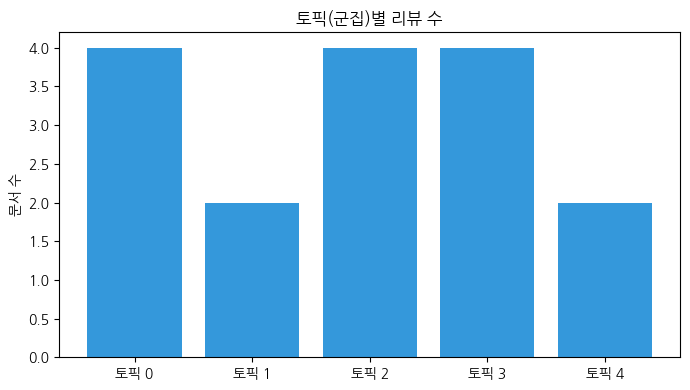

In [8]:
# ✅ [제공 코드] 토픽별 대표 단어 + 군집 크기 시각화
import numpy as np
terms = vectorizer.get_feature_names_out()

print('🔑 토픽별 대표 단어 (군집 중심에서 가중치 높은 단어):')
for c in range(NUM_TOPICS):
    top_idx = km.cluster_centers_[c].argsort()[::-1][:5]
    print(f'  토픽 {c}: {[terms[i] for i in top_idx]}')

counts = pd.Series(labels).value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar([f'토픽 {i}' for i in counts.index], counts.values, color='#3498db')
plt.title('토픽(군집)별 리뷰 수')
plt.ylabel('문서 수')
plt.tight_layout()
plt.show()

## ✏️ TODO 3: 새 리뷰는 어느 토픽일까?

학습된 군집 모델로 **새 리뷰**가 어느 토픽에 속하는지 예측해봅니다.

In [7]:
# ✏️ TODO 3: 새 리뷰를 같은 vectorizer로 변환하고 토픽을 예측하세요
new_reviews = [
    '배송 상자가 또 찌그러져서 왔어요',
    '환불 절차가 복잡하고 가격도 비싸요',
    '상담 직원이 빠르게 답변했어요',
]

new_X = vectorizer.transform(new_reviews)    # ← new_reviews · 새 문서. 기존 사전으로 transform만(fit 금지!) 해야 동일 기준 적용
pred  = km.predict(new_X)              # ← new_X · 변환된 새 벡터를 학습된 모델로 토픽 예측

for review, topic in zip(new_reviews, pred):
    print(f'  [토픽 {topic}]  {review}')

  [토픽 0]  배송 상자가 또 찌그러져서 왔어요
  [토픽 4]  환불 절차가 복잡하고 가격도 비싸요
  [토픽 3]  상담 직원이 빠르게 답변했어요


---
## 🔗 실무로 연결하기

오늘 체험한 '라벨 없이 묶기'가 실무에서는 이렇게 쓰입니다.

`수천 건 리뷰·VOC` → `토픽 모델링(군집)` → `토픽별 비중·추이` → `대시보드`

- **신상품 출시 후** 어떤 주제(배송·품질·가격)의 언급이 급증하는지 자동 포착
- 라벨을 미리 만들 수 없는 **새로운 이슈**도 군집으로 드러남 (지도학습의 한계 보완)
- 대량·정기 분석은 Comprehend **관리형 토픽 모델링**(비동기 잡)으로 자동화
- 군집 결과에 **감성 분석(Lab 1)** 을 결합하면 '어떤 주제가 부정적인지'까지 파악

## 💡 심화 도전
1. `NUM_TOPICS` 를 3, 5, 6으로 바꿔가며 군집이 어떻게 달라지는지 관찰하세요.
2. 실제 리뷰 30개를 직접 입력해 토픽을 뽑아보세요.
3. 각 토픽의 리뷰에 Lab 1의 `detect_sentiment` 를 적용해 '토픽별 평균 감성'을 구해보세요.

## ✅ 정답 코드

👆 모두 풀고 난 후 확인하세요

```python
# TODO 1
X = vectorizer.fit_transform(sample_docs)

# TODO 2
km = KMeans(n_clusters=NUM_TOPICS, random_state=42, n_init=10)
labels = km.fit_predict(X)

# TODO 3
new_X = vectorizer.transform(new_reviews)
pred  = km.predict(new_X)
```